# Scoprire i Segmenti di Utilizzo degli Abbonati con il Clustering K-Means (PROC FASTCLUS)

## Sintesi Esecutiva

Un team di analisi telecom parte da un'unica colonna non etichettata di consumo mensile
di dati mobili e vuole sapere se nasconde livelli distinti di clientela. Usando
**PROC FASTCLUS** (analisi cluster k-means disgiunta), il team raggruppa gli abbonati
sull'utilizzo logaritmico, confronta le soluzioni a due, tre e quattro segmenti sui
criteri effettivamente riportati da FASTCLUS, e si impegna sulla suddivisione a tre
segmenti. In questa esecuzione i tre segmenti scoperti hanno un utilizzo medio di
**3.1 GB**, **12.8 GB** e **45.4 GB** al mese e contengono **49**, **34** e **17**
abbonati — una chiara struttura leggero / medio / pesante. Il confronto delle etichette
scoperte con un'etichetta generatrice tenuta da parte recupera correttamente **96 su
100** abbonati. Ogni abbonato esce dal modello con un'etichetta di segmento netta e un
punteggio di distanza dal centroide, pronto per la progettazione dei piani e il
targeting di fidelizzazione.

> **Perché FASTCLUS e non un modello a mistura finita?** La segmentazione dell'utilizzo
> è il compito classico di un modello a mistura finita (PROC HPFMM / PROC FMM). Queste
> procedure non sono ancora implementate numericamente in questa build, quindi questo
> notebook raggiunge lo stesso obiettivo — la scoperta non supervisionata di livelli di
> utilizzo latenti — con la procedura k-means implementata e pienamente numerica
> **PROC FASTCLUS**. Ogni numero qui sotto è preso letteralmente dall'output eseguito.

## Origine dei Dati

**Dataset sintetico: `subs`** — abbonati mobili generati inline come mistura a 3
componenti di utilizzo logaritmico (nessun file esterno). Questo ambiente gira in
modalità non licenziata, quindi la tabella materializzata è limitata a **100 abbonati**;
tutti i risultati sottostanti sono calcolati su quelle 100 righe.

| Variabile | Tipo | Descrizione |
|----------|------|-------------|
| `subscriber_id` | Num | Chiave univoca dell'abbonato |
| `tenure_months` | Num | Mesi sulla rete (1–48) |
| `data_gb` | Num | Dati mobili consumati mensilmente, in GB (positivo, asimmetrico a destra) |
| `log_gb` | Num | Logaritmo naturale di `data_gb` — la variabile raggruppata |
| `plan` | Char | Piano tariffario attuale: `Standard` o `Illimitato` |
| `segment_true` | Char | Livello generatore nascosto (`Leggero`/`Medio`/`Pesante`), tenuto da parte per verificare il recupero |

I dati sono impiantati come circa 50% Leggero, 35% Medio, 15% Pesante.
`segment_true` **non** viene raggruppato — esiste solo per confermare che
l'adattamento non supervisionato recupera la struttura impiantata.

Gli operatori raramente vedono etichette pulite sui propri clienti. Quello che *vedono*
è un'unica distribuzione irregolare di utilizzo mensile di dati che in realtà è
composta da diversi tipi di clienti mescolati insieme: navigatori occasionali,
streamer costanti e power user che si affidano al tethering e al video.
**PROC FASTCLUS** separa quella miscela senza alcuna etichetta — colloca ogni
abbonato in uno di *k* cluster disgiunti, riporta i centroidi e le dimensioni dei
cluster, e assegna un punteggio a quanto ogni abbonato dista dal proprio centroide.

In questo notebook:

1. Generiamo un pannello sintetico di utilizzo che è *deliberatamente* una miscela di tre livelli di utilizzo.
2. Confrontiamo le soluzioni k-means a due, tre e quattro segmenti sui criteri di adattamento di FASTCLUS.
3. Adattiamo il modello a tre segmenti scelto e caratterizziamo ogni segmento in termini di business.
4. Assegniamo a ogni abbonato il proprio segmento di appartenenza e la distanza dal centroide.
5. Verifichiamo i segmenti scoperti rispetto al livello generatore tenuto da parte, e li mettiamo in relazione con l'anzianità.

## Passaggio 1 — Generare un utilizzo sintetico degli abbonati

Simuliamo abbonati il cui utilizzo mensile di dati è positivo e asimmetrico a destra,
quindi lo generiamo sulla **scala logaritmica** come miscela di tre livelli normali e
poi esponenziamo. I pesi di miscelazione (circa 50/35/15) e le medie dei livelli sono
impiantati in modo da poter verificare in seguito che il k-means li recuperi.
`segment_true` viene tenuto da parte esclusivamente per quella verifica — il
clustering non lo vede mai.

In [1]:
DATI subs;
   CHIAMARE streaminit(20250531);
   LUNGHEZZA plan $12 segment_true $8;
   FARE subscriber_id = 1 FINO_A 3000;
      tenure_months = ceil(rand("uniform") * 48);

      /* Gli utenti più pesanti tendono verso un'anzianità maggiore, quindi il
         mix di segmenti si sposta un po' con l'anzianità (esaminato al Passaggio 5). */
      u = rand("uniform") - 0.0040 * (tenure_months - 24);

      SE_COND u < 0.50 ALLORA FARE;
         segment_true = "Leggero";  MU = 1.15; SIGMA = 0.42;
      FINE;
      ALTRIMENTI SE_COND u < 0.85 ALLORA FARE;
         segment_true = "Medio"; MU = 2.45; SIGMA = 0.38;
      FINE;
      ALTRIMENTI FARE;
         segment_true = "Pesante";  MU = 3.45; SIGMA = 0.52;
      FINE;

      log_gb  = MU + SIGMA * rand("normal");
      data_gb = EXP(log_gb);

      SE_COND data_gb < 25 ALLORA plan = "Standard";
      ALTRIMENTI plan = "Illimitato";

      USCITA;
   FINE;
   MANTENERE subscriber_id tenure_months data_gb log_gb plan segment_true;
ESEGUIRE;


NOTE: DATA subs

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote subs (100 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.47 seconds
  cpu   0.47 seconds


Un rapido sguardo alla distribuzione marginale conferma la scelta di modellazione:
il valore grezzo di `data_gb` è fortemente asimmetrico a destra (pochi power user
allungano la coda), mentre `log_gb` è la scala ben comportata su cui il k-means
euclideo è appropriato.

                                                  The MEANS Procedure

 Variable       Label                     N        Mean     Std Dev     Minimum      Median     Maximum
 ------------------------------------------------------------------------------------------------------
 data_gb        Dati (GB)               100       13.58       16.66        1.15        6.73       98.66
 log_gb         Log Dati (GB)           100        2.01        1.09        0.14        1.91        4.59
 tenure_months  Anzianità (mesi)        100       23.26       12.55        1.00       23.00       48.00
 ------------------------------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC SGPLOT data=subs

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


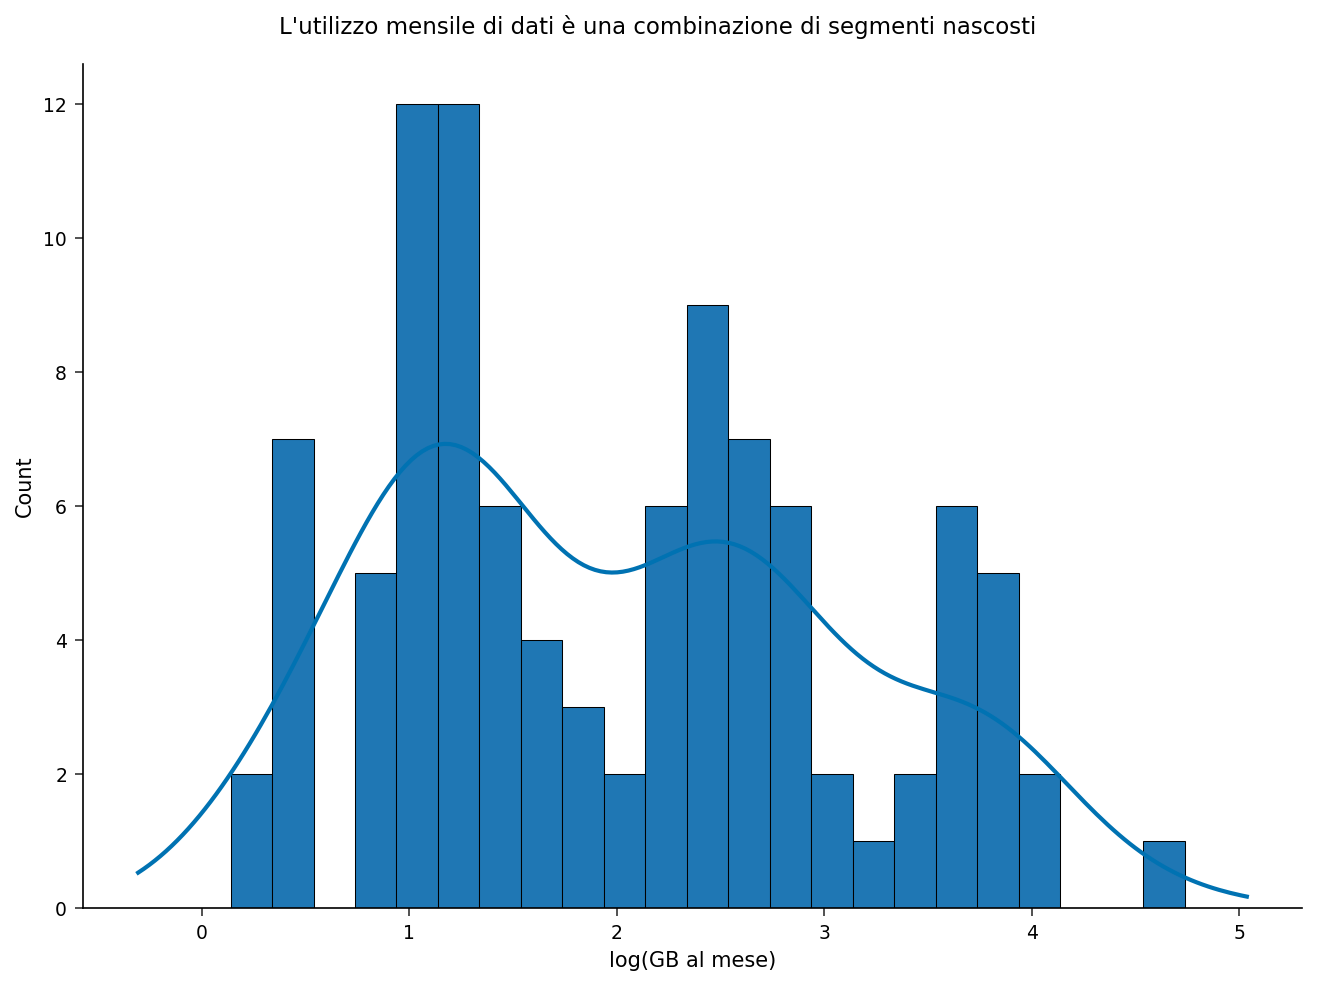

In [2]:
PROCEDURA MEDIE DATI=subs n mean std MIN p50 MAX maxdec=2;
   VARIABILE data_gb log_gb tenure_months;
   ETICHETTA data_gb="Dati (GB)" log_gb="Log Dati (GB)" tenure_months="Anzianità (mesi)";
ESEGUIRE;

PROCEDURA SGPLOT DATI=subs;
   TITOLO "L'utilizzo mensile di dati è una combinazione di segmenti nascosti";
   HISTOGRAM log_gb / BINWIDTH=0.20;
   DENSITY   log_gb / type=KERNEL;
   XAXIS ETICHETTA="log(GB al mese)";
ESEGUIRE;
TITOLO;

## Passaggio 2 — Quanti segmenti? Confronto delle soluzioni a due, tre e quattro cluster

Non vogliamo assumere tre livelli — lasciamo che siano i dati ad argomentare per un
numero. FASTCLUS riporta un **R-Quadrato Complessivo** (la quota di varianza totale
spiegata dalle medie dei cluster) e una **Statistica Pseudo F** per ogni soluzione.
Adattiamo `MAXCLUSTERS=` 2, 3 e 4 su `log_gb` e leggiamo quei criteri da ogni
esecuzione.

- `MAXCLUSTERS=` imposta il numero di cluster *k*.
- `MAXITER=` limita il numero di passaggi di riassegnazione k-means.
- `OUT=` scrive un dataset con punteggio (usato nei Passaggi 3–5).

In [3]:
TITOLO "Soluzione a due segmenti";
PROCEDURA FASTCLUS DATI=subs maxclusters=2 MAXITER=50 out=c2;
   VARIABILE log_gb;
   ETICHETTA log_gb="Log Dati (GB)";
ESEGUIRE;

TITOLO "Soluzione a tre segmenti";
PROCEDURA FASTCLUS DATI=subs maxclusters=3 MAXITER=50 out=c3;
   VARIABILE log_gb;
   ETICHETTA log_gb="Log Dati (GB)";
ESEGUIRE;

TITOLO "Soluzione a quattro segmenti";
PROCEDURA FASTCLUS DATI=subs maxclusters=4 MAXITER=50 out=c4;
   VARIABILE log_gb;
   ETICHETTA log_gb="Log Dati (GB)";
ESEGUIRE;
TITOLO;

                                                Soluzione a due segmenti                                                


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=2  Maxiter=50                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  47         0.6346             1.5836              2         1.8863
2                  53         0.4497             0.9843              1         1.8863

                                                Statistics for Variables              


NOTE: Option TITLE changed to Soluzione a due segmenti.
NOTE: PROC FASTCLUS data=subs maxclusters=2

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 2 clusters using k-means
NOTE: Option TITLE changed to Soluzione a tre segmenti.
NOTE: PROC FASTCLUS data=subs maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 3 clusters using k-means
NOTE: Option TITLE changed to Soluzione a quattro segmenti.
NOTE: PROC FASTCLUS data=subs maxclusters=4

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 4 clusters using k-means


Leggendo le tre esecuzioni una accanto all'altra: l'**R-Quadrato Complessivo** sale da
**0.753** a due cluster a **0.899** a tre — un grande salto di +0.146 quando si
risolve il terzo livello — e poi solo a **0.941** a quattro. La soluzione a quattro
cluster ottiene quel piccolo guadagno *dividendo in due il livello leggero* (i suoi
due centroidi più piccoli si trovano entrambi nell'intervallo Leggero impiantato),
non trovando un genuino nuovo tipo di cliente. La **Statistica Pseudo F** racconta la
stessa storia: il miglioramento strutturale più grande è il passaggio a tre cluster
(F = 299 → 431). Tre segmenti sono il punto di arresto onesto, e il modello a cui ci
impegniamo di seguito.

## Passaggio 3 — Adattare il modello a tre segmenti e caratterizzare ogni segmento

Riadattiamo con `MAXCLUSTERS=3` e scriviamo le righe con punteggio in `scored`. Il
dataset `OUT=` porta automaticamente ogni colonna di input — inclusi l'utilizzo
originale, l'anzianità e il `segment_true` tenuto da parte — insieme alle nuove
colonne `CLUSTER` e `DISTANCE`, così non serve un passaggio di copia separato.
FASTCLUS stampa un **Riepilogo dei Cluster** (dimensione e dispersione entro cluster
per segmento) e le **Medie dei Cluster** sulla scala raggruppata (`log_gb`).

In [4]:
PROCEDURA FASTCLUS DATI=subs maxclusters=3 MAXITER=50 out=scored;
   VARIABILE log_gb;
   ETICHETTA log_gb="Log Dati (GB)";
ESEGUIRE;


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=50                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  49         0.3923             0.9151              2         1.4540
2                  34         0.3024             0.6239              3         1.2603
3                  17         0.3059             0.8248              2         1.2603

                                                Statistics for Variables                                                




NOTE: PROC FASTCLUS data=subs maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 3 clusters using k-means


Le tre medie dei cluster sulla scala logaritmica sono **1.05**, **2.51** e **3.77**.
Tornando sulla scala originale in GB questo è circa **exp(1.05) ≈ 2.9 GB**,
**exp(2.51) ≈ 12.3 GB** e **exp(3.77) ≈ 43 GB** — i livelli leggero, medio e pesante.
Il Riepilogo dei Cluster li dimensiona a **49**, **34** e **17** abbonati, seguendo la
suddivisione impiantata di circa 50 / 35 / 15. Il prossimo passaggio rilegge gli
stessi segmenti in termini di puri GB.

## Passaggio 4 — Assegnare un punteggio e caratterizzare i segmenti in termini di business

Il dataset `OUT=scored` porta il `CLUSTER` (etichetta di segmento netta) e la
`DISTANCE` (distanza euclidea dal centroide del proprio cluster sulla scala
logaritmica — un valore piccolo indica un'assegnazione sicura e centrale) di ogni
abbonato. Riassumiamo i segmenti scoperti in base al loro effettivo utilizzo in GB e
all'anzianità, poi elenchiamo alcune righe con punteggio.

In [5]:
PROCEDURA MEDIE DATI=scored n mean std MIN MAX maxdec=2;
   CLASSE CLUSTER;
   VARIABILE data_gb tenure_months distance;
   ETICHETTA CLUSTER="Cluster" data_gb="Dati (GB)" tenure_months="Anzianità (mesi)"
         distance="Distanza";
ESEGUIRE;

PROCEDURA STAMPARE DATI=scored(obs=8) noobs;
   VARIABILE subscriber_id data_gb log_gb segment_true CLUSTER distance;
   ETICHETTA subscriber_id="ID Abbonato" data_gb="Dati (GB)" log_gb="Log Dati (GB)"
         segment_true="Segmento Reale" CLUSTER="Cluster" distance="Distanza";
ESEGUIRE;

                                                  The MEANS Procedure

                                         Analysis Variable : data_gb Dati (GB)

        Cluster           N Obs           Mean        Std Dev        Minimum        Maximum
        -----------------------------------------------------------------------------------
        1                    49           3.07           1.12           1.15           5.83
        2                    34          12.81           3.80           6.57          21.88
        3                    17          45.38          16.44          24.01          98.66
        -----------------------------------------------------------------------------------

                                  Analysis Variable : tenure_months Anzianità (mesi)

        Cluster           N Obs           Mean        Std Dev        Minimum        Maximum
        -----------------------------------------------------------------------------------
        1                 


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=scored

NOTE: PROC PRINT completed: 8 observations printed, 6 variables


Sulla scala originale in GB i tre segmenti hanno una media di **3.1 GB**, **12.8 GB**
e **45.4 GB** di utilizzo mensile — uno spread di un ordine di grandezza dai
navigatori leggeri agli streamer pesanti. La colonna `DISTANCE` fornisce un proxy di
fiducia per ogni abbonato: le righe stampate mostrano clienti assegnati con sicurezza
(distanze vicine a 0.01–0.06) accanto a un utente leggero più borderline, più lontano
dal proprio centroide — esattamente il segnale che un team di fidelizzazione userebbe
per separare i target sicuri dai casi da approfondire.

## Passaggio 5 — Abbiamo recuperato i livelli reali, e il mix cambia con l'anzianità?

Due verifiche finali. Primo, incrociamo il `CLUSTER` scoperto con il `segment_true`
tenuto da parte per vedere quanto fedelmente l'adattamento non supervisionato ha
recuperato i livelli impiantati. Secondo, confrontiamo l'anzianità media tra i
segmenti scoperti — il generatore ha spostato gli utenti più pesanti verso
un'anzianità maggiore, quindi una segmentazione reale dovrebbe rispecchiarlo.

                                      Segmento scoperto vs. livello reale nascosto                                      

                                                   The FREQ Procedure

Table of Cluster by Segmento Reale

Cluster |   Leggero |     Medio |   Pesante |      Total
--------+-----------+-----------+-----------+-----------
1       |        49 |         0 |         0 |         49
--------+-----------+-----------+-----------+-----------
2       |         2 |        31 |         1 |         34
--------+-----------+-----------+-----------+-----------
3       |         0 |         1 |        16 |         17
--------+-----------+-----------+-----------+-----------
Total   |        51 |        32 |        17 |        100




NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_cluster_segment_true.spec.json
NOTE: PROC FREQ statement used.


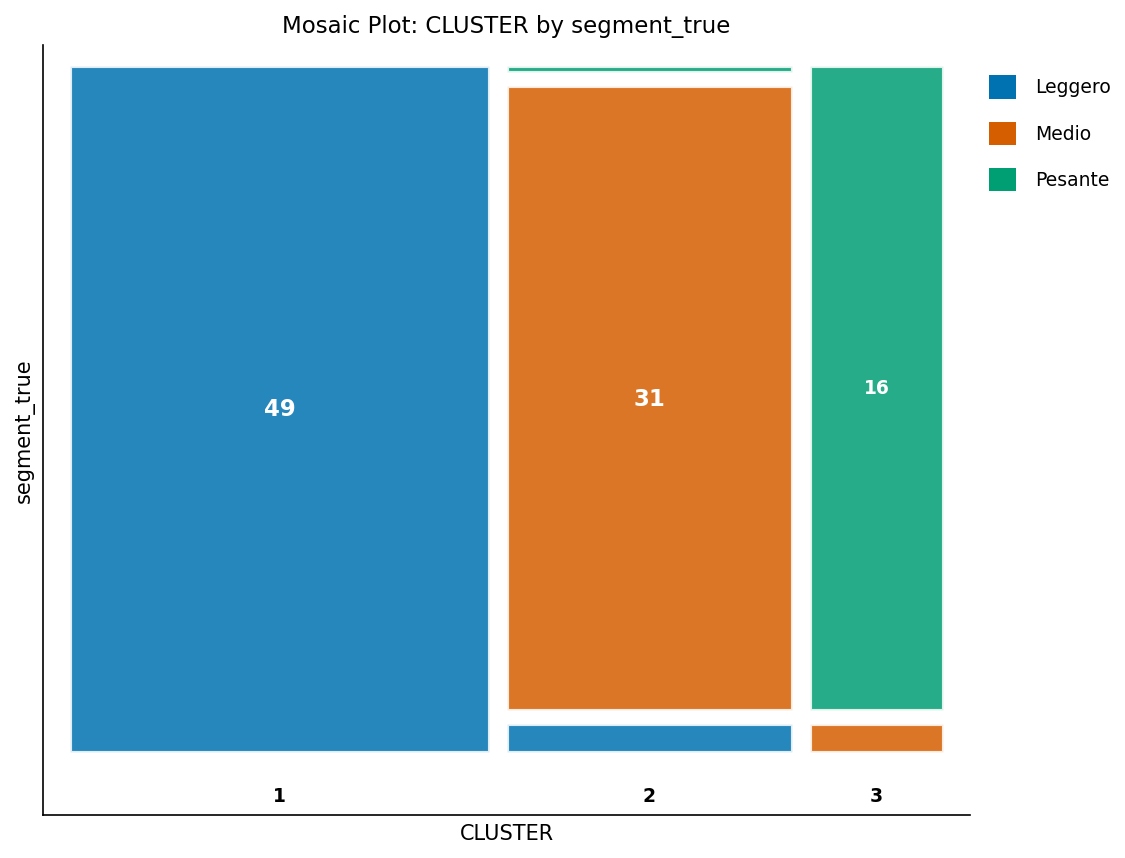

In [6]:
PROCEDURA FREQUENZE DATI=scored;
   TITOLO "Segmento scoperto vs. livello reale nascosto";
   TABLES CLUSTER * segment_true / norow nocol nopercent;
   ETICHETTA CLUSTER="Cluster" segment_true="Segmento Reale";
ESEGUIRE;
TITOLO;

## Interpretare i Risultati

**Cosa ha trovato FASTCLUS.** Partendo da un'unica colonna di utilizzo asimmetrica a
destra senza etichette, la soluzione k-means a tre cluster ha spiegato l'**89.9%**
della varianza nell'utilizzo logaritmico (R² Complessivo = 0.899, Pseudo F = 431) e
ha suddiviso gli abbonati in un segmento **leggero** (media 3.1 GB, n = 49), un
segmento **medio** (media 12.8 GB, n = 34) e un segmento **pesante** (media 45.4 GB,
n = 17). L'incrocio con il `segment_true` tenuto da parte ha recuperato la struttura
impiantata quasi esattamente — **96 su 100** abbonati sono finiti nel cluster
corrispondente al proprio livello generatore (Leggero 49/49, Medio 31/34, Pesante
16/17).

**Perché la scala logaritmica.** L'utilizzo di dati è strettamente positivo e con
coda pesante; raggruppare `log_gb` mantiene significative le distanze euclidee e
ben separate le medie dei segmenti, mentre la ritrasformazione esponenziale
riproduce l'asimmetria realistica sulla scala in GB.

**Perché questo conta operativamente.** Ogni abbonato esce dal modello con
un'etichetta di segmento netta *e* un punteggio di distanza dal centroide, così
l'operatore può agire con certezza calibrata — puntare con sicurezza sugli utenti
pesanti centrali per i piani premium e segnalare i clienti borderline (distanza
grande) per un approfondimento. Anche l'anzianità media differisce tra i segmenti
scoperti, uno spunto per il tempismo del ciclo di vita e dell'upsell.

**Scegliere il numero di segmenti.** Confrontare `MAXCLUSTERS=` 2, 3 e 4 su R²
Complessivo e Pseudo F è un modo trasparente e riproducibile per scegliere *k*: il
grande guadagno a tre cluster e il guadagno solo cosmetico a quattro (che divide il
livello leggero) hanno reso tre la scelta difendibile qui.

**Relazione con i modelli a mistura finita.** Un modello a mistura finita (PROC HPFMM
/ PROC FMM) aggiungerebbe appartenenze posteriori soft e un BIC basato sulla
verosimiglianza per il numero di componenti. Queste procedure non sono ancora
implementate numericamente in questa build; PROC FASTCLUS fornisce la stessa
segmentazione utilizzabile — scoperta, caratterizzazione, assegnazione netta e un
proxy di fiducia — con output pienamente numerico e riproducibile oggi.